# Chapter 2 Frequency Distributions Supplementary Problems

19. (a) Arrange the numbers $12, 56, 42, 21, 5, 18, 10, 3, 61, 34, 65,$ and $24$ in an array and (b) determine the range.

In [1]:
(a <- sort(c( 12, 56, 42, 21,
              5,  18, 10, 3,
              61, 34, 65, 24  )))
diff(range(a))

[1]  3  5 10 12 18 21 24 34 42 56 61 65

[1] 62

---

20. The table `p20.t` shows the frequency distribution for the number of minutes per week spent watching TV by $400$ junior high students. WIth reference to this table determine:

| Viewing Time (minutes) | Number of Students |
|:----------------------:|:------------------:|
|         300-399        |         14         |
|         400-499        |         46         |
|         500-599        |         58         |
|         600-699        |         76         |
|         700-799        |         68         |
|         800-899        |         62         |
|         900-999        |         48         |
|        1000-1099       |         22         |
|        1100-1199       |          6         |

The following vector will define the frequencies:

In [2]:
p20.f <- c(14, 46, 58, 76, 68, 62, 48, 22, 6)

The symbols: `300-399`, `400-499`, etc..., represent the _class intervals_. The numbers `300`, `400`, etc... represent the _lower limits_, and the numbers `399`, `499`, etc... represent the _upper limits_:

In [3]:
p20.ll <- seq(300, 1100, by=100)
p20.ul <- seq(399, 1199, by=100)

_Class boundaries_ are generally created by adding the upper limit of one class interval to the lower limit of the next-higher class interval and dividing by 2. However, in R we will use _open-closed_ intervals.

We generate some random values, based on the frequency in each class:

In [4]:
set.seed(1245)
p20.s1 <- c()
for(i in 1:length(p20.f)){
    iter.sample <- sample(p20.ll[i]:p20.ul[i], p20.f[i], replace=TRUE)
    p20.s1 <- sample(c(p20.s1, iter.sample))
}

We construct the table using the values in `p20.s1`, the `breaks` variable will be the _lower limits_ plus $1200$ to complete the last _class interval_.

In [5]:
p20.breaks <- seq(300, 1200, by=100)
(p20.t <- table(cut(p20.s1,breaks=p20.breaks, right=FALSE)))


        [300,400)         [400,500)         [500,600)         [600,700) 
               14                46                58                76 
        [700,800)         [800,900)       [900,1e+03)   [1e+03,1.1e+03) 
               68                62                48                22 
[1.1e+03,1.2e+03) 
                6 

The generated table `p20.t` is an exact replica of the table above. The table is closed on the left size indicated by the `[` bracket in the _class interval_.

(a) The upper limit of the fifth class:

In [6]:
p20.ul[5]

[1] 799

(b) The lower limit of the eigth class:

In [7]:
p20.ll[8]

[1] 1000

(c) The class mark of the seventh class:

In [8]:
(p20.ul[7]+p20.ll[7])/2

[1] 949.5

(d) The class boundary of the last class:

In [9]:
(p20.lc.lb <- (p20.ll[9] + p20.ul[8])/2)
(p20.lc.ub <- p20.ul[9] + .5)

[1] 1099.5

[1] 1199.5

(e) The class-interval size:

In [10]:
(p20.interval.size <- diff(p20.breaks)[1])

[1] 100

(f) The frequency of the fourth class:

In [11]:
p20.t[[4]]

[1] 76

(g) The relative frequency of the sixth class:

In [12]:
as.vector(p20.t/sum(p20.t)*100)[6]

[1] 15.5

(h) The percentage of students whose weekly viewing time does not exceed  600 minutes:

In [13]:
sum(as.vector(p20.t/sum(p20.t)*100)[1:3])

[1] 29.5

(i) The percentage of students whose weekly viewing time is greater than or equal to 900 minutes:

In [14]:
sum(as.vector(p20.t/sum(p20.t)*100)[9:7])

[1] 19

(j) The percentage of students whose viewing times are at least 500 minutes but less than 1000 minutes:

In [15]:
100 - sum(as.vector(p20.t/sum(p20.t)*100)[1:2]) - sum(as.vector(p20.t/sum(p20.t)*100)[9:8])

[1] 78

---

21. Construct (a) a histogram and (b) a frequency polygon corresponding to the frequency distribution of Table `p20.t`.

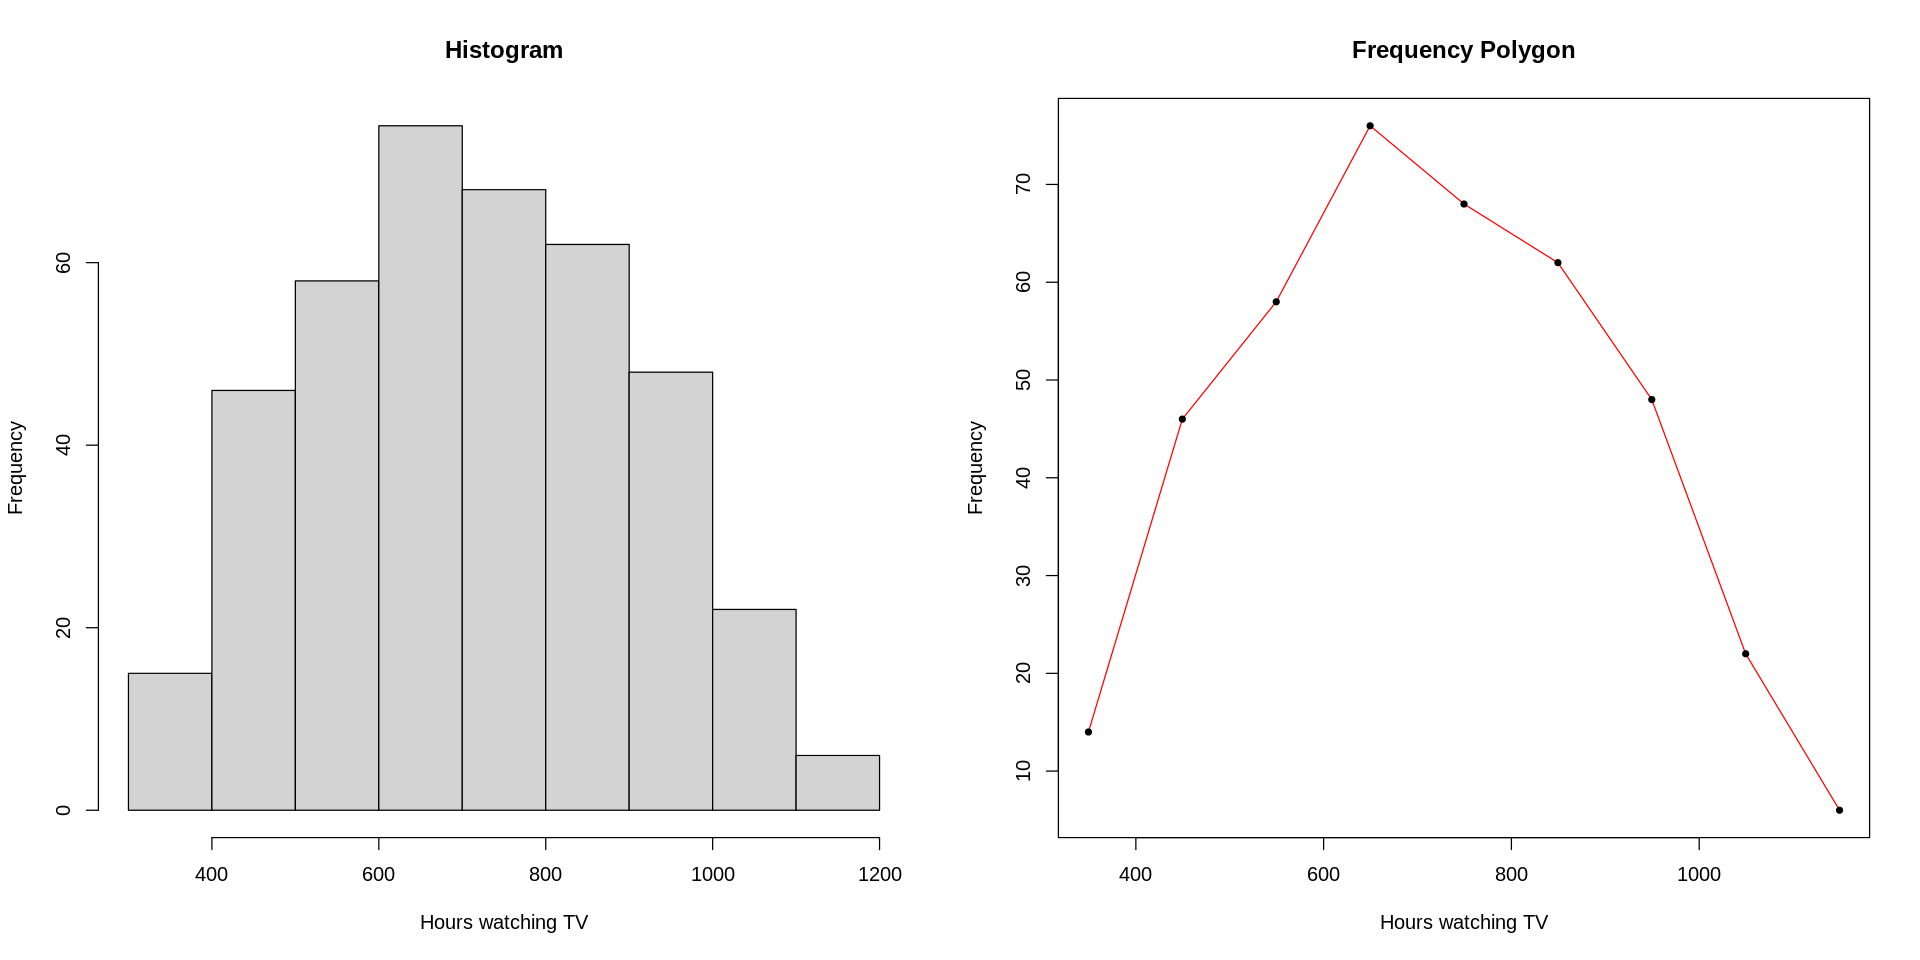

In [16]:
p21.X <- p21.marks <- (p20.ul + p20.ll)/2
p21.f <- as.vector(p20.t)
par(mfrow=c(1,2))
options(repr.plot.width=16, repr.plot.height=8)
p21.h <- hist(p20.s1,xlab="Hours watching TV",main="Histogram")
plot(p21.X,p21.f,type="l",col='red',ylab="Frequency",xlab="Hours watching TV",main="Frequency Polygon")
points(p21.X,p21.f,pch=20)
options(repr.plot.width=7, repr.plot.height=7)

---

22. For the data in Table `p20.t` construct (a) a relative-frequency distribution, (b) a relative-frequency histogram, and (c) a relative-frequency polygon.

__NOTE__: How to create a histogram from a frequency distribution?


        [300,400)         [400,500)         [500,600)         [600,700) 
              3.5              11.5              14.5              19.0 
        [700,800)         [800,900)       [900,1e+03)   [1e+03,1.1e+03) 
             17.0              15.5              12.0               5.5 
[1.1e+03,1.2e+03) 
              1.5 

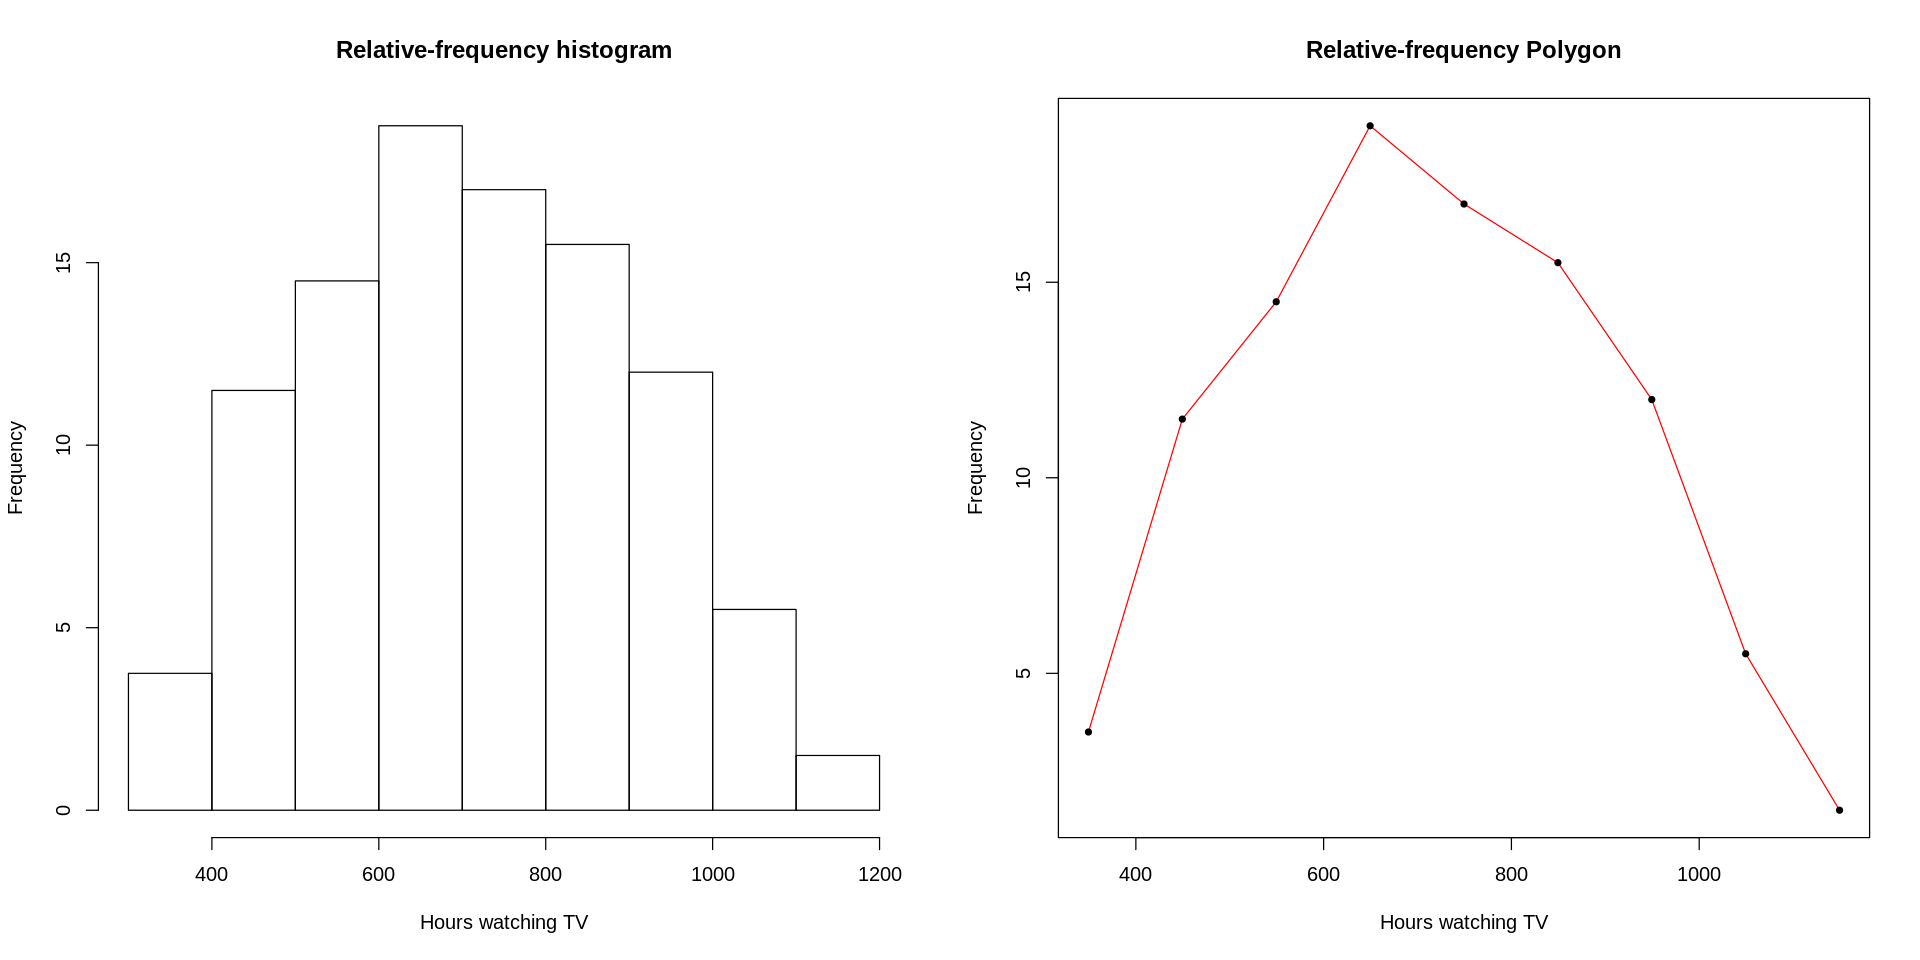

In [17]:
(p22.rel.t <- p20.t/sum(p20.t)*100)
p22.h.rel <- p21.h
p22.h.rel$counts <- p21.h$counts/sum(p21.h$counts)*100
p22.rel.f <- as.vector(p22.rel.t)
par(mfrow=c(1,2))
options(repr.plot.width=16, repr.plot.height=8)
plot(p22.h.rel,main="Relative-frequency histogram", xlab="Hours watching TV")
plot(p21.X,p22.rel.f,type="l",col="red", main="Relative-frequency Polygon", xlab="Hours watching TV", ylab="Frequency")
points(p21.X,p22.rel.f,pch=20)
options(repr.plot.width=7, repr.plot.height=7)

---

23. For the data in Table `p20.t`, construct (a) a cumulative-frequency distribution, (b) a percentage cumulative distribution, (c) an ogive, and (d) a percentage ogive. (Note that unless otherwise specified, a cumulative distribution refers to one made on a "less than" basis.)

[1]  14  60 118 194 262 324 372 394 400

[1]   3.5  15.0  29.5  48.5  65.5  81.0  93.0  98.5 100.0

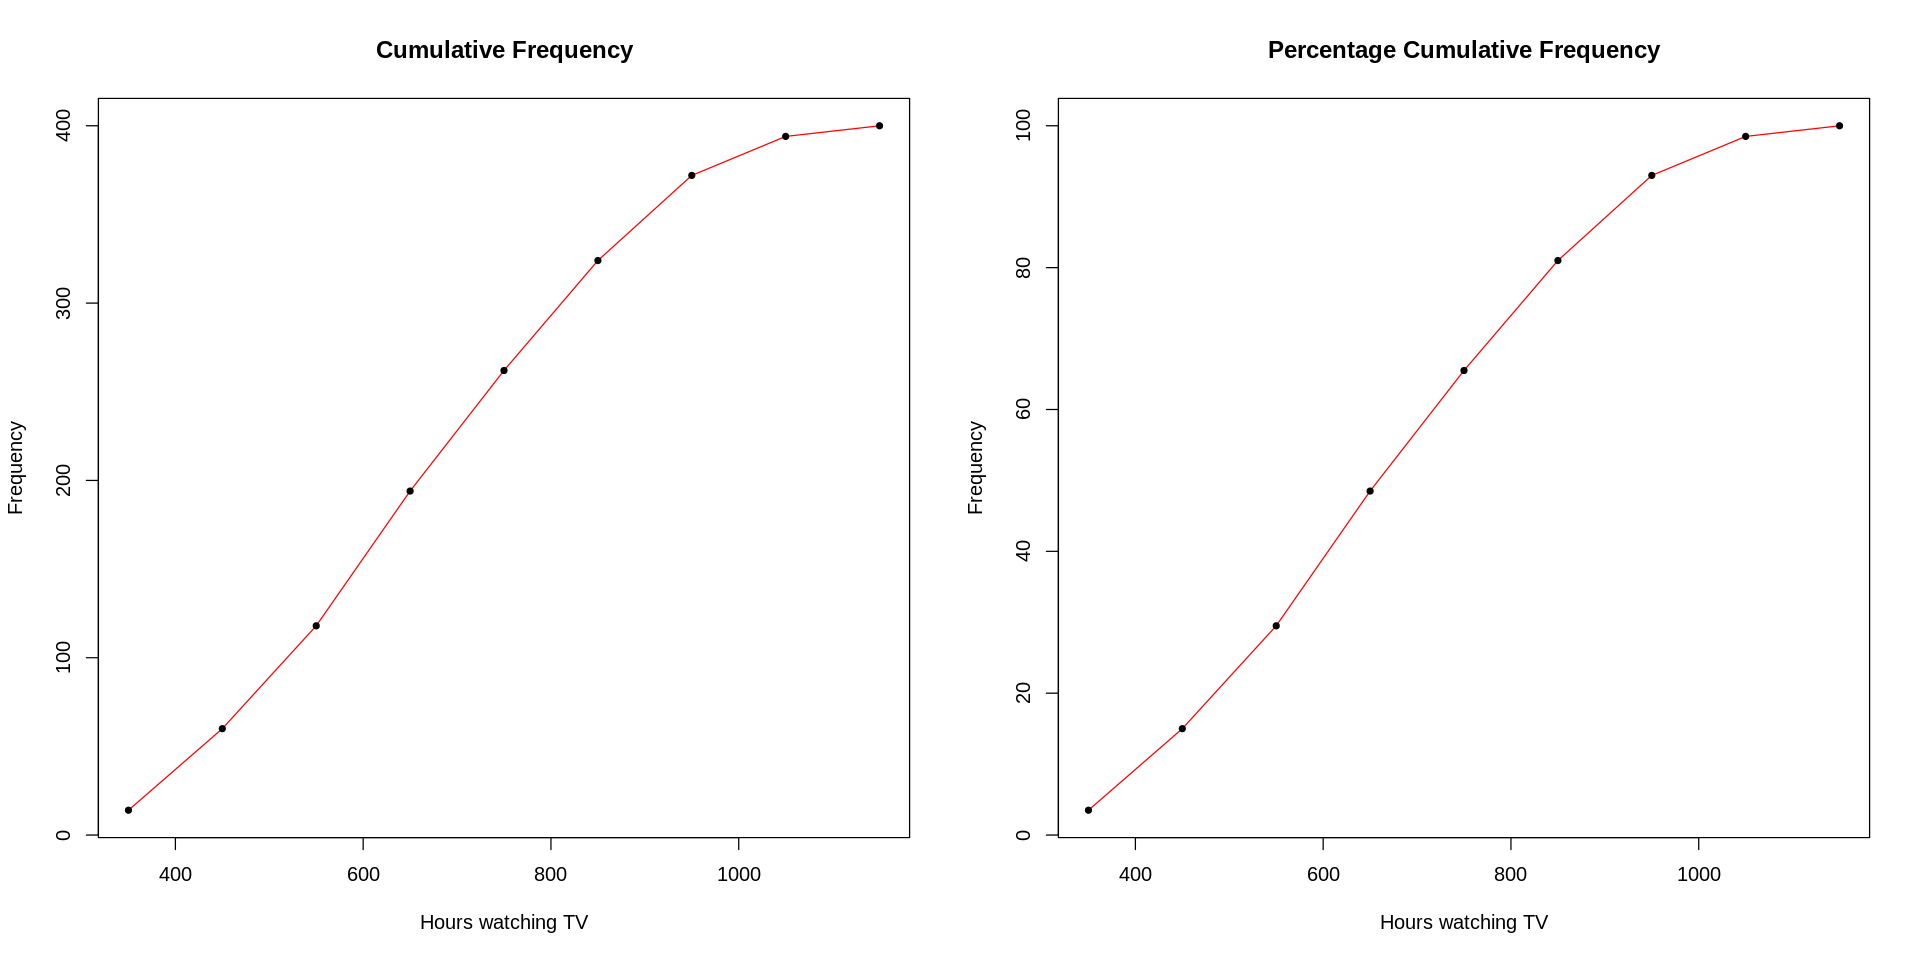

In [18]:
(p23.cum.freq <- cumsum(p21.f))
(p23.rel.cum.freq <- p23.cum.freq/sum(p21.f)*100)
p23.X <- p21.h$mids
par(mfrow=c(1,2))
options(repr.plot.width=16, repr.plot.height=8)
plot(p23.X,p23.cum.freq,type="l",col="red",main="Cumulative Frequency",xlab="Hours watching TV",ylab="Frequency")
points(p23.X,p23.cum.freq,pch=20)
plot(p23.X,p23.rel.cum.freq,type="l",col="red",main="Percentage Cumulative Frequency", xlab="Hours watching TV",ylab="Frequency")
points(p23.X,p23.rel.cum.freq,pch=20)
options(repr.plot.width=7, repr.plot.height=7)

---

24. Work Problem 2.23 for the case where the frequencies are cumulative on an "or more" basis.

[1] 400 386 340 282 206 138  76  28   6

[1] 100.0  96.5  85.0  70.5  51.5  34.5  19.0   7.0   1.5

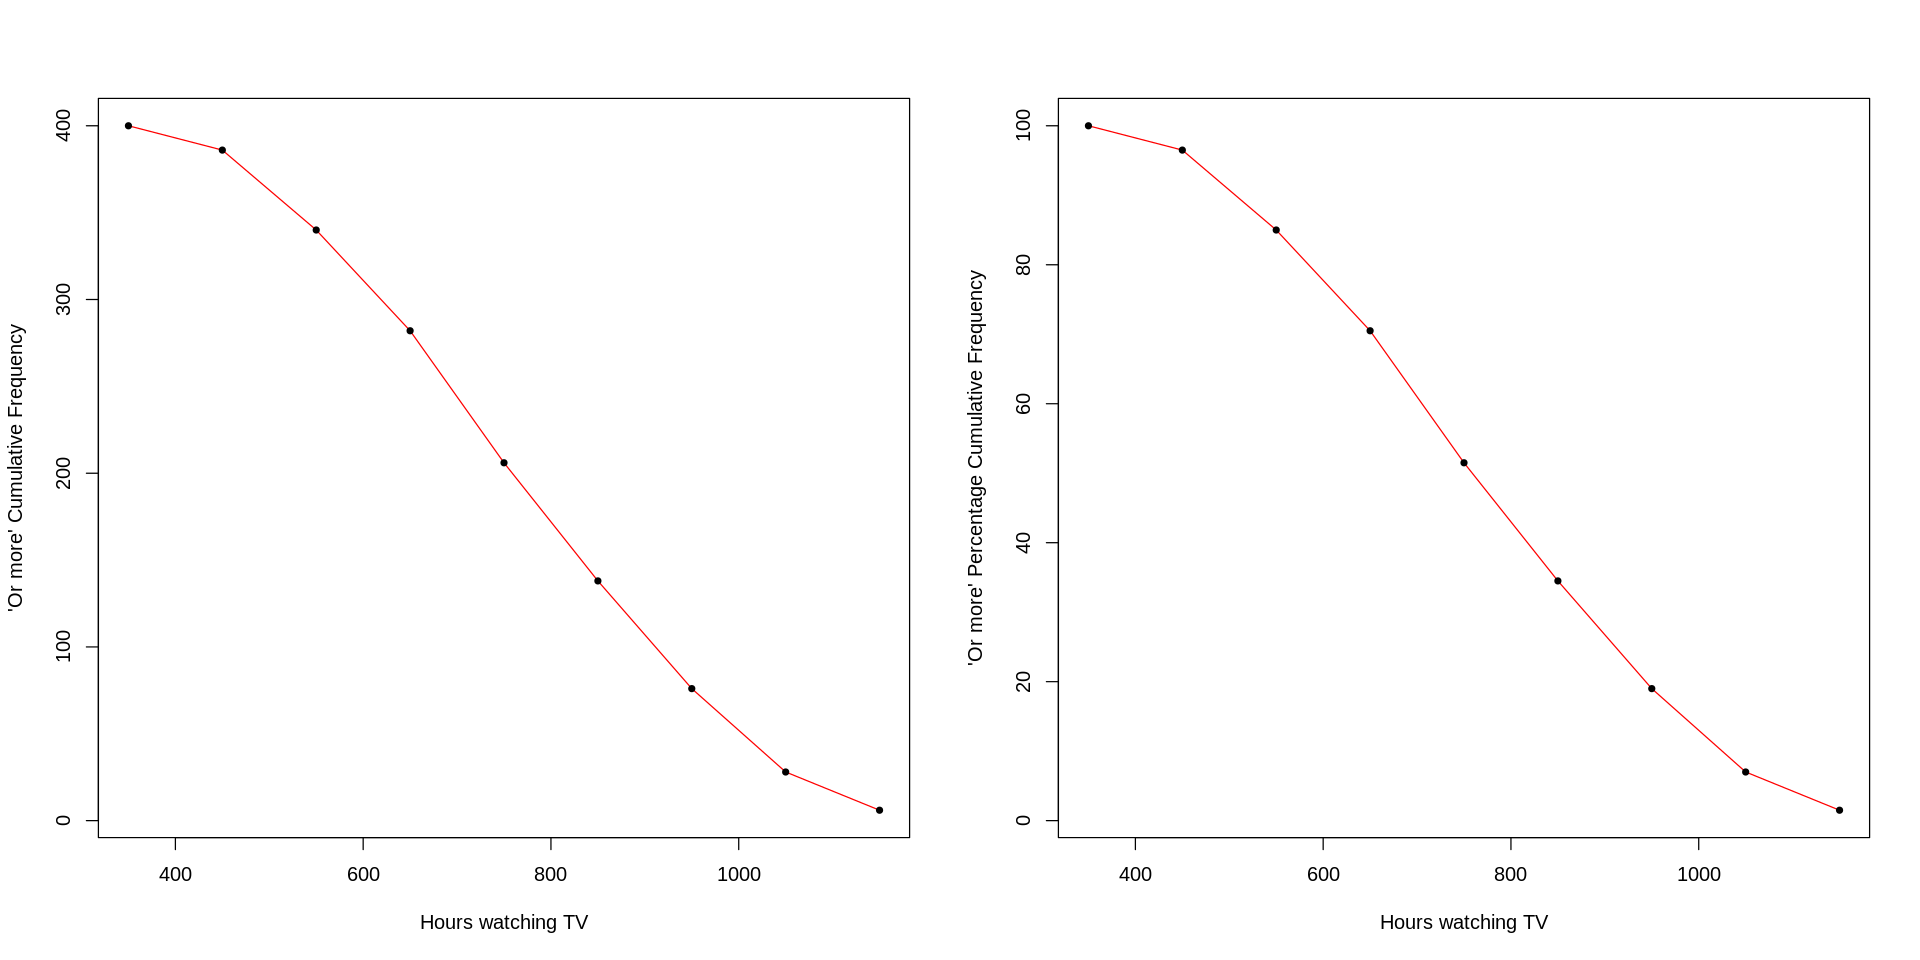

In [19]:
(p24.rev.cum.freq <- rev(cumsum(p21.f[length(p21.f):1])))
(p24.rev.rel.cum.freq <- p24.rev.cum.freq/sum(p21.f)*100)
par(mfrow=c(1,2))
options(repr.plot.width=16, repr.plot.height=8)
plot(p23.X,p24.rev.cum.freq,type="l",col="red",ylab="'Or more' Cumulative Frequency", xlab="Hours watching TV")
points(p23.X,p24.rev.cum.freq,pch=20)
plot(p23.X,p24.rev.rel.cum.freq,type="l",col="red",ylab="'Or more' Percentage Cumulative Frequency", xlab="Hours watching TV")
points(p23.X,p24.rev.rel.cum.freq,pch=20)
options(repr.plot.width=7, repr.plot.height=7)

---

25. Using the data in Table 2.15,, estimate the percentage of students that have viewing times of (a) less than 560 minutes per week, (b) 970 or more minutes per week, and (c) between 620 and 890 minutes per week.
__NOTE__: Need to assess significant digits. The 

(a) less than 560 minutes per week:

In [20]:
(p25.lessthan.560 <- p23.rel.cum.freq[2] + round(p22.rel.f[3]*.6))

[1] 24

(b) 970 or more minutes per week

In [21]:
(p25.ormore.970 <- p24.rev.rel.cum.freq[8] + round(p22.rel.f[7]*.3))

[1] 11

(c) between 620 and 890 minutes per week:

In [22]:
p25.lessthan.620.partial <- ((620-p20.ll[4])/p20.interval.size)
p25.ormore.890.partial <- ((p20.ul[6]-890)/p20.interval.size)
p25.lessthan.620 <- p23.rel.cum.freq[3] + p22.rel.f[4]*p25.lessthan.620.partial
p25.ormore.890 <- p24.rev.rel.cum.freq[7] + p22.rel.f[6]*p25.ormore.890.partial
round(100 - p25.lessthan.620 - p25.ormore.890) 

[1] 46

---

26. The inner diameters of washers produced by a company can be measured to the nearest thousandth of an inch. If the class marks of a frequency distribution of these diameters are given in inches by $0.321$, $0.324$, $0.327$, $0.330$, $0.333$, and $0.336$, find (a) the class-interval size, (b) the class boundaries, and (c) the class limits.

In [23]:
p26.marks <- c(0.321, 0.324, 0.327, 0.330, 0.333, 0.336)

(a) the class-interval size:

In [24]:
(p26.interval.size <- diff(p26.marks)[1])

[1] 0.003

(b) the class boundaries:

In [25]:
(p26.b <- c(p26.marks - p26.interval.size/2, tail(p26.marks,1) + p26.interval.size/2))

[1] 0.3195 0.3225 0.3255 0.3285 0.3315 0.3345 0.3375

(c) the class limits:

__Note__: How do we calculate the differentials? They should come from the boundaries.

In [26]:
(p26.ll <- p26.b[1:length(p26.b)-1] + 0.0005)
(p26.ul <- p26.b[2:length(p26.b)] - 0.0005)

[1] 0.320 0.323 0.326 0.329 0.332 0.335

[1] 0.322 0.325 0.328 0.331 0.334 0.337

---

27. The following table shows the diameters in centimeters (cm) of a sample of 60 ball bearings manufactured by a company.

In [27]:
p27.s1 <- c( 1.738, 1.729, 1.743, 1.740, 1.736, 1.741, 1.735, 1.731, 1.726, 1.737,
             1.728, 1.737, 1.736, 1.735, 1.724, 1.733, 1.742, 1.736, 1.739, 1.735,
             1.745, 1.736, 1.742, 1.740, 1.728, 1.738, 1.725, 1.733, 1.734, 1.732,
             1.733, 1.730, 1.732, 1.730, 1.739, 1.734, 1.738, 1.739, 1.727, 1.735,
             1.735, 1.732, 1.735, 1.727, 1.734, 1.732, 1.736, 1.741, 1.736, 1.744,
             1.732, 1.737, 1.731, 1.746, 1.735, 1.735, 1.729, 1.734, 1.730, 1.740)

Construct a frequency distribution of the diameters, using appropriate class intervals.


[1.72,1.725) [1.725,1.73) [1.73,1.735) [1.735,1.74) [1.74,1.745) [1.745,1.75) 
           1            8           17           23            9            2 

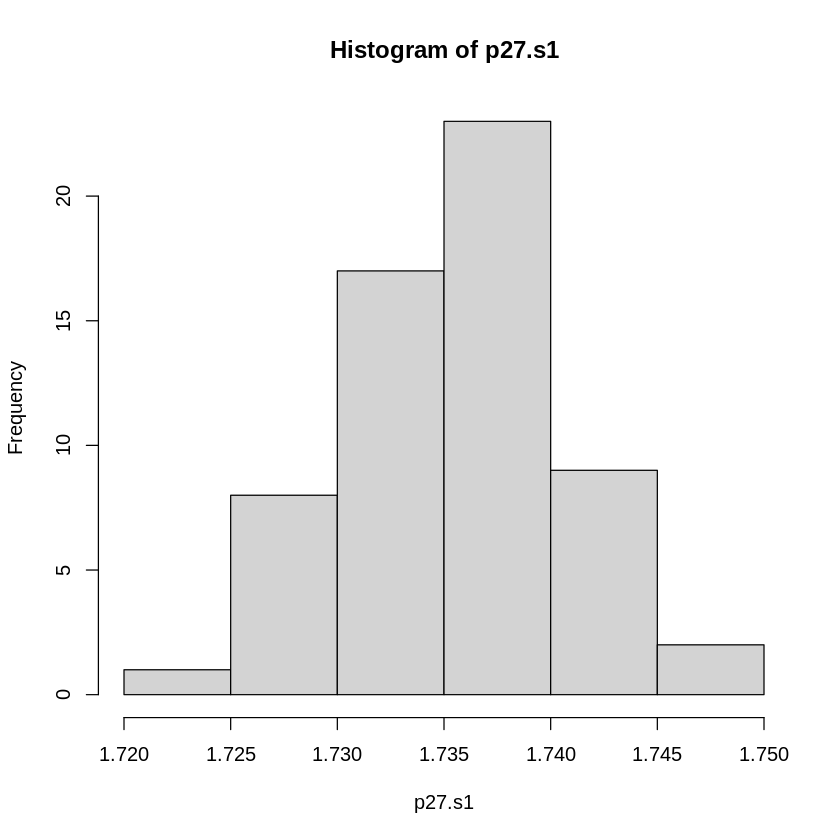

In [28]:
p27.h <- hist(p27.s1,right=FALSE)
(p27.t <- table(cut(p27.s1,p27.h$breaks,right=FALSE)))

---

28. For the data of Problem 27 construct (a) a histogram, (b) a frequency polygon, (c) a relative-frequency distribution, (d) a relative-frequency histogram, (e) a relative-frequency polygon, (f) a cumulative-frequency distribution, (g) a percentage cumulative distribution, (h) an ogive, and (i) a percentage ogive.

(a) a histogram and (b) a frequency polygon:

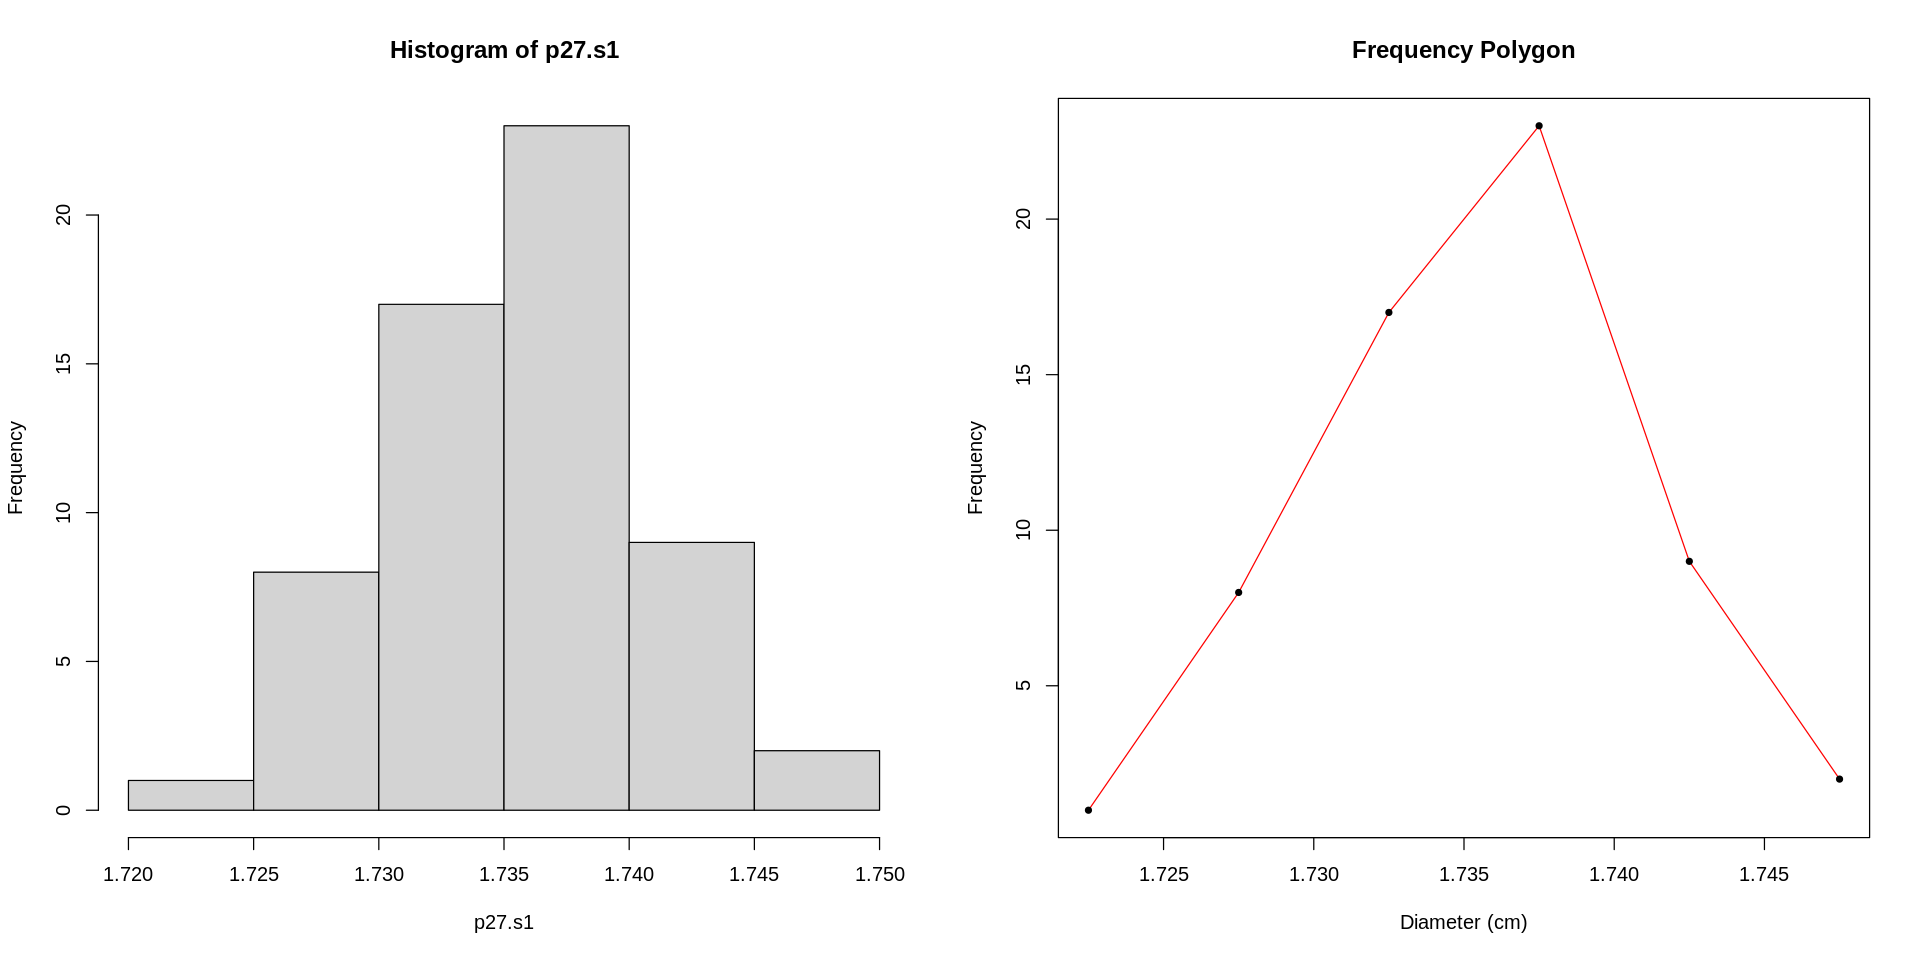

In [29]:
par(mfrow=c(1,2))
options(repr.plot.width=16, repr.plot.height=8)
p27.h <- hist(p27.s1,right=FALSE)
plot(p27.h$mids,p27.h$counts,type="l",col="red", main="Frequency Polygon", ylab="Frequency", xlab="Diameter (cm)")
points(p27.h$mids,p27.h$counts,pch=20)
options(repr.plot.width=7, repr.plot.height=7)

(c) a relative-frequency distribution, (d) a relative-frequency histogram, (e) and a relative-frequency polygon:


[1.72,1.725) [1.725,1.73) [1.73,1.735) [1.735,1.74) [1.74,1.745) [1.745,1.75) 
        1.67        13.33        28.33        38.33        15.00         3.33 

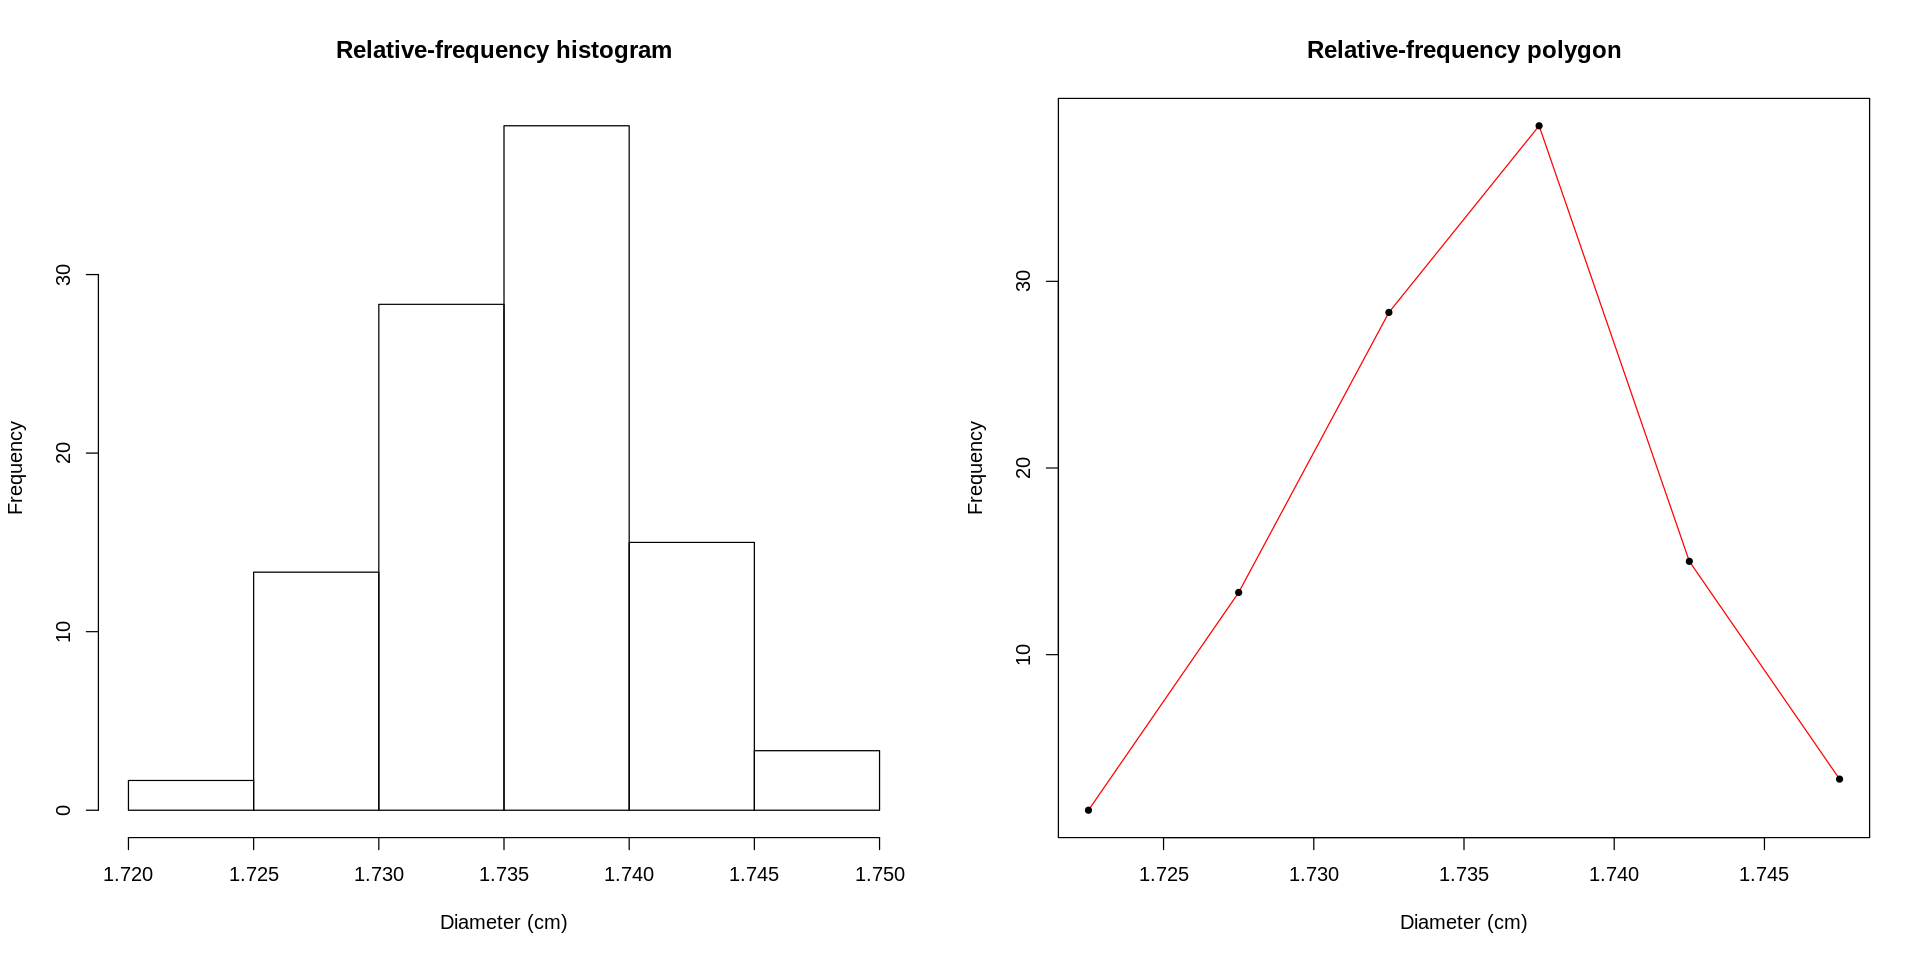

In [30]:
(p28.rel.t <- round(p27.t/sum(p27.t)*100,2))
p28.rel.h <- p27.h
p28.rel.h$counts <- p27.h$counts/sum(p27.h$counts)*100
par(mfrow=c(1,2))
options(repr.plot.width=16, repr.plot.height=8)
plot(p28.rel.h, main="Relative-frequency histogram", xlab="Diameter (cm)")
plot(p28.rel.h$mids,p28.rel.h$counts,type="l",col="red",main="Relative-frequency polygon", ylab="Frequency", xlab="Diameter (cm)")
points(p28.rel.h$mids, p28.rel.h$counts,pch=20)
options(repr.plot.width=7, repr.plot.height=7)

(f) a cumulative-frequency distribution, (g) a percentage cumulative distribution, (h) an ogive, and (i) a percentage ogive:

[1.72,1.725) [1.725,1.73) [1.73,1.735) [1.735,1.74) [1.74,1.745) [1.745,1.75) 
           1            9           26           49           58           60

[1.72,1.725) [1.725,1.73) [1.73,1.735) [1.735,1.74) [1.74,1.745) [1.745,1.75) 
           2           15           43           82           97          100

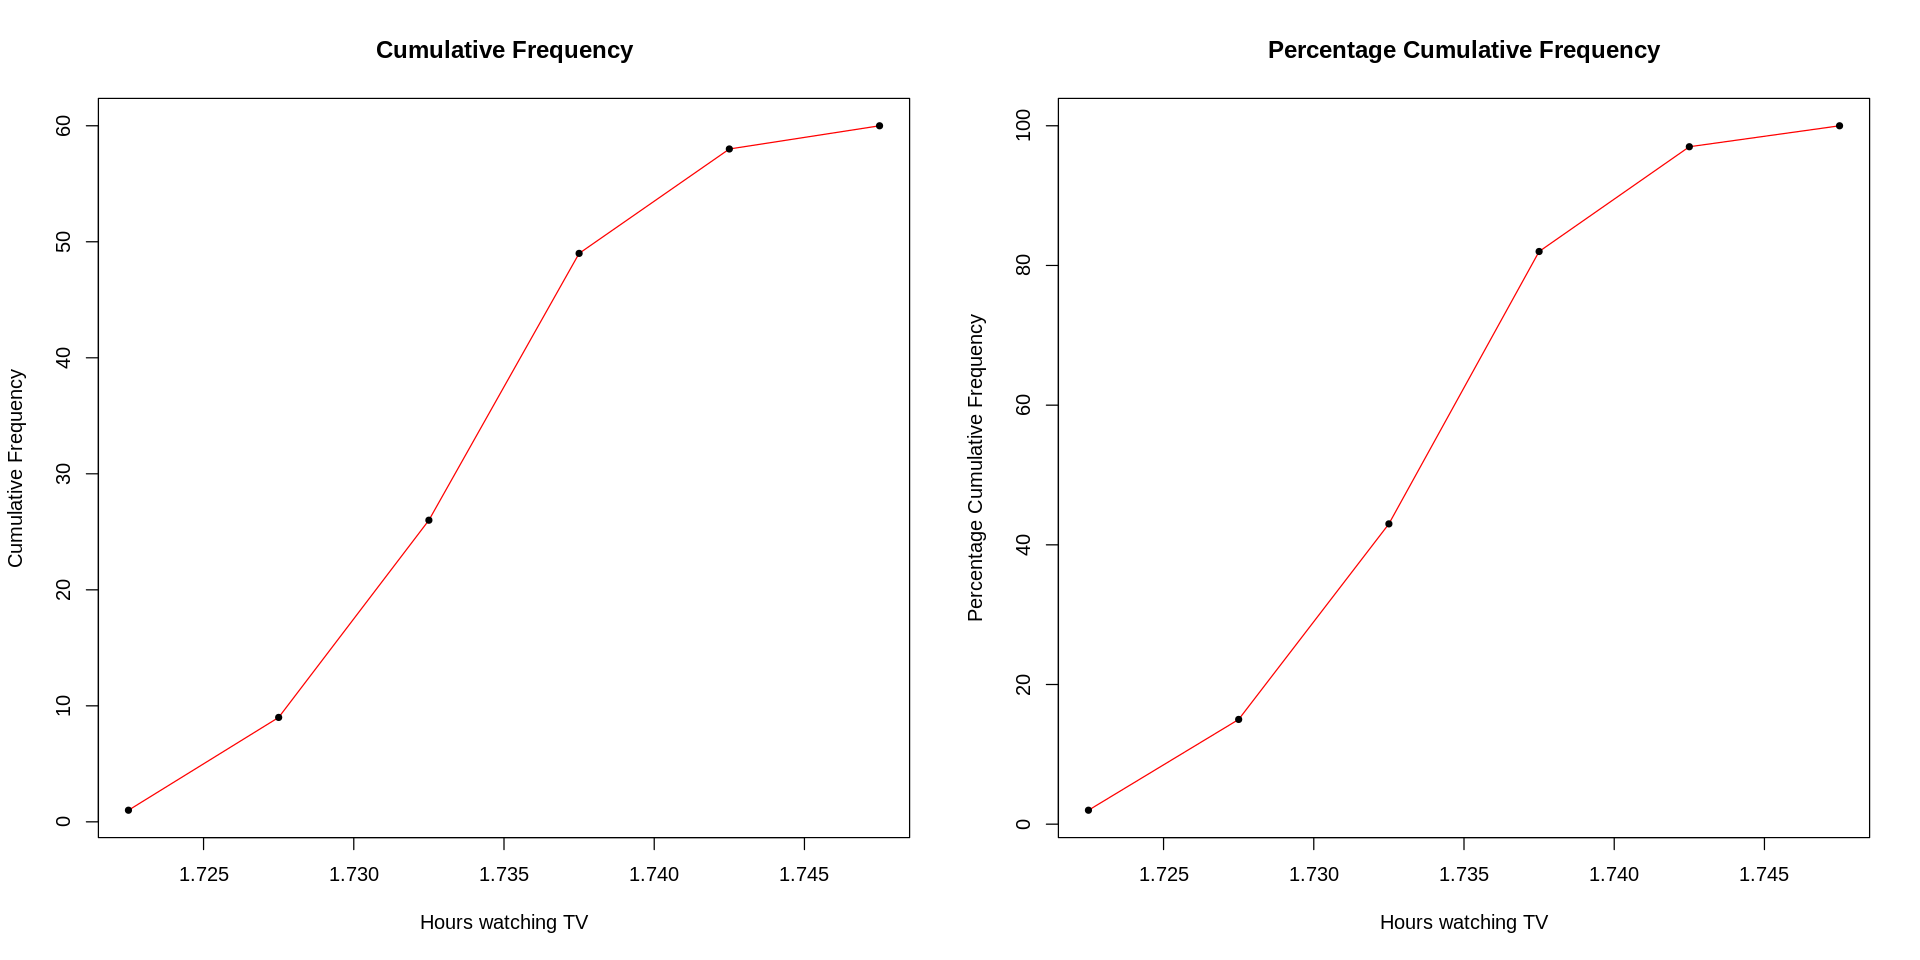

In [31]:
(p28.cum.t <- cumsum(p27.t))
(p28.rel.cum.t <- round(cumsum(p28.rel.t)))
p28.X <- p27.h$mids
par(mfrow=c(1,2))
options(repr.plot.width=16, repr.plot.height=8)
plot(p28.X,as.vector(p28.cum.t),type="l",col="red",main="Cumulative Frequency",ylab="Cumulative Frequency",xlab="Hours watching TV")
points(p28.X,as.vector(p28.cum.t),pch=20)
plot(p28.X,as.vector(p28.rel.cum.t),type="l",col="red",main="Percentage Cumulative Frequency",ylab="Percentage Cumulative Frequency",
     xlab="Hours watching TV")
points(p28.X,as.vector(p28.rel.cum.t),pch=20)
options(repr.plot.width=7, repr.plot.height=7)

---

29. From the results in Problem 28, determine the percentage of ball berings having diameters (a) exceeding 1.732 cm, (b) not more than 1.736 cm, and (c) between 1.730 and 1.738 cm. Compare your results with those obtained directly from the raw data of Problem 27.

(a) diameters exceeding 1.732 cm

Using a reverse cumulation table, the answer will be an estimate. Because $1.732$ is $60\%$ of the interval, we can guess that $60\%$ of the frequency value in the interval $1.73$&mdash;$1.735$ will exceed $1.732$cm. Here are the reverse cumulative values:

In [32]:
(p29.rev.cum <- as.vector(cumsum(rev(p27.t))))

[1]  2 11 34 51 59 60

The relative cumulations:

In [33]:
(p29.rev.rel.cum <- round(as.vector(cumsum(rev(p27.t)))/sum(p27.t)*100,2))

[1]   3.33  18.33  56.67  85.00  98.33 100.00

Now to display the cumulation frequency plots:

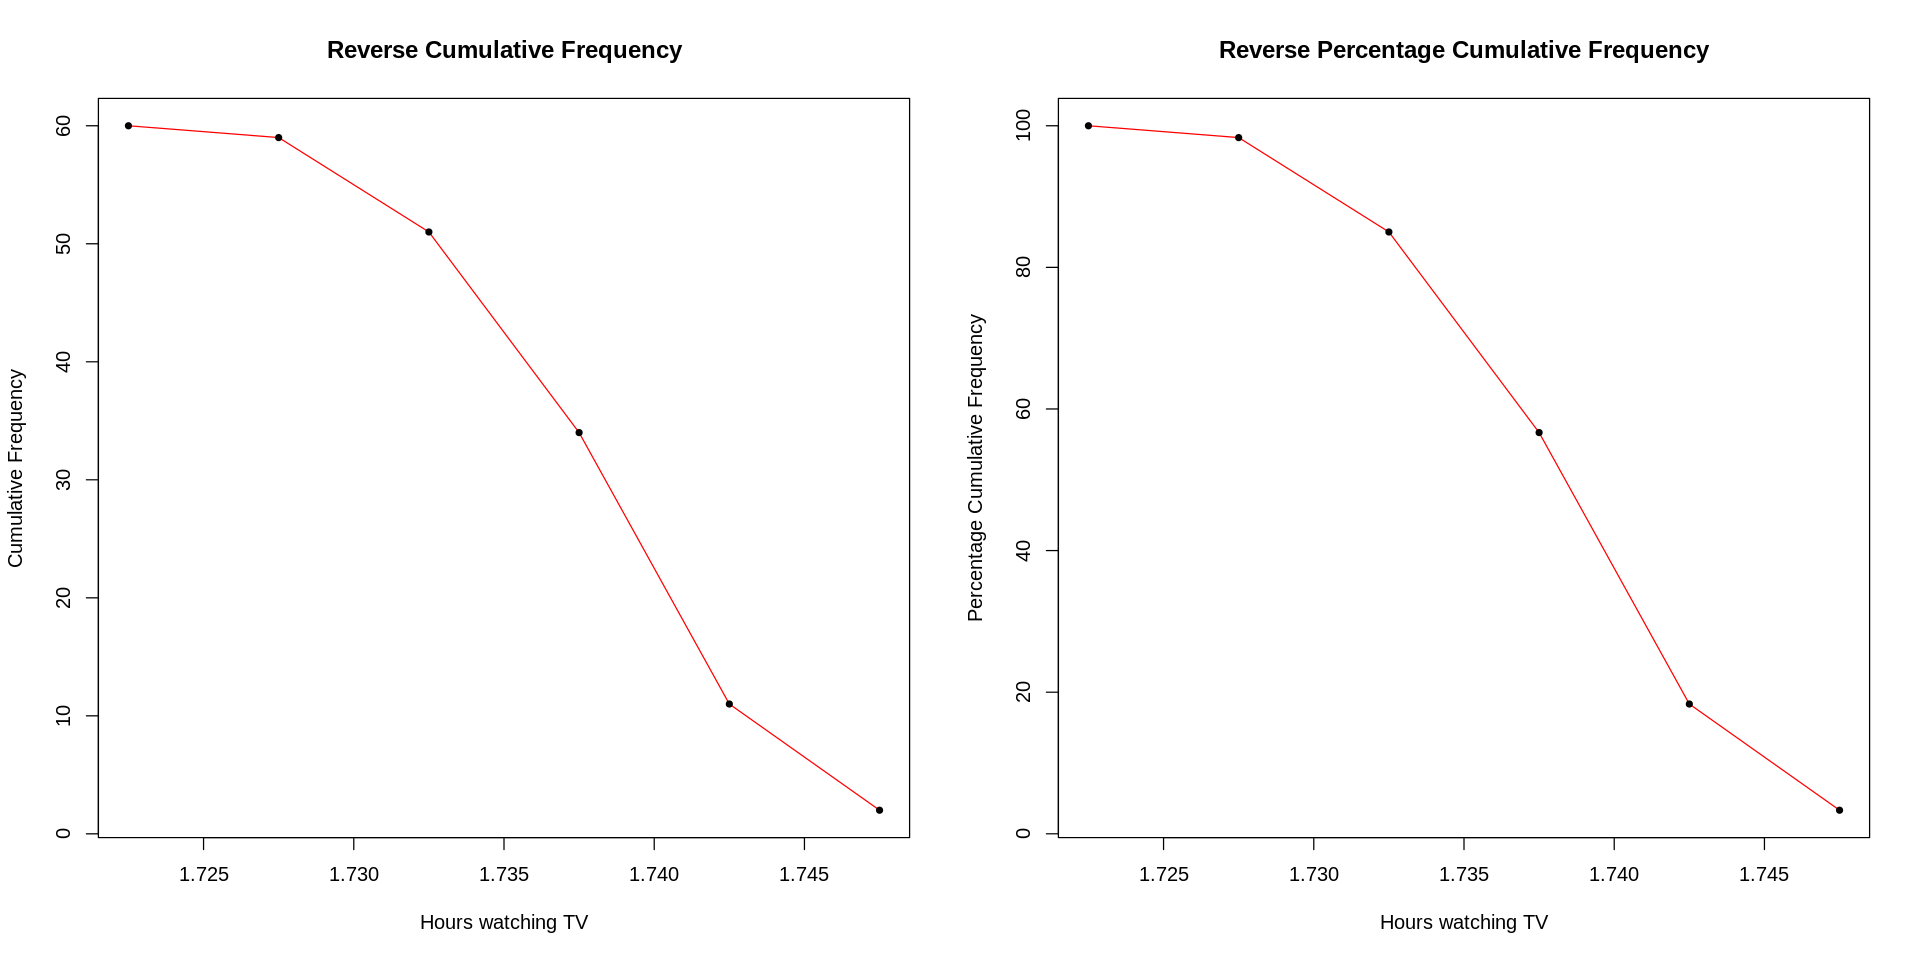

In [34]:
p29.rev.X <- rev(p28.X)
par(mfrow=c(1,2))
options(repr.plot.width=16, repr.plot.height=8)
plot(p29.rev.X,p29.rev.cum,type="l",col="red",main="Reverse Cumulative Frequency",ylab="Cumulative Frequency",xlab="Hours watching TV")
points(p29.rev.X,p29.rev.cum,pch=20)
plot(p29.rev.X,p29.rev.rel.cum,type="l",col="red",main="Reverse Percentage Cumulative Frequency",ylab="Percentage Cumulative Frequency",
     xlab="Hours watching TV")
points(p29.rev.X,p29.rev.rel.cum,pch=20)
options(repr.plot.width=7, repr.plot.height=7)

Estimating the cumulated diameters exceeding $1.732$:

In [41]:
p29.rel.f <- as.vector(p28.rel.t)
p29.interval.size <- round(diff(p27.h$mids)[1],4)
p29.1732.rel.interval <- round((1.735 - 1.732)/p29.interval.size,4)
(p29.exceed.1732 <- p29.rev.rel.cum[3] + p29.rel.f[3]*p29.1732.rel.interval)

[1] 73.668

The real value and the error percent (which is high):

In [36]:
(p29.1732.real.value <- round(length(p27.s1[(p27.s1 > 1.732)])/length(p27.s1),4)*100)

[1] 68.33

Estimating the cumulated diameters not more than $1.736$ cm:

In [54]:
(p29.rel.cum <- as.vector(p28.rel.cum.t))
(p29.1736.rel.interval <- round((1.736 - 1.735)/p29.interval.size,4))
(p29.notmorethan.1736 <- round(p29.rel.cum[2] + p29.rel.f[3]*p29.1736.rel.interval,2))
#p29.1736.slice <- round(p27.t[[4]]*p29.1736.rel.interval)
#(p29.notmorethan.1736 <- as.vector(p28.cum.t[3]) + p29.1736.slice)

[1]   2  15  43  82  97 100

[1] 0.2

[1] 20.67

In [53]:
(p29.1736.real.value <- length(p27.s1[(p27.s1 <= 1.736)]))/length(p27.s1)

[1] 0.6666667

Between 1.730 and 1.738 cm:

In [39]:
p29.upto.1730 <- p28.cum.t[[2]]
p29.greaterthan.1738 <- p29.rev.cum[2] + round(p27.t[[3]]*round((1.74 - 1.738)/p29.interval.size,4),4)
(p29.between.1730.1738 <- 60 - p29.upto.1730 - p29.greaterthan.1738)

[1] 33.2

In [40]:
(p29.between.1730.1738.real.value <- length(p27.s1[(p27.s1 <= 1.739 & p27.s1 >= 1.730)]))
(p29.between.error <- round(abs(p29.between.1730.1738.real.value - p29.between.1730.1738)/p29.between.1730.1738.real.value*100,2))

[1] 40

[1] 17